In [1]:
!pip install transformers datasets evaluate scikit-learn matplotlib seaborn torch

  Using cached xxhash-3.6.0-cp312-cp312-win_amd64.whl.metadata (13 kB)
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 8.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/27.6 MB ? eta -:--:--
   ----- ---------------------------------- 3.9/27.6 MB 19.5 MB/s eta 0:00:02
   ----------- ---------------------------- 7.9/27.6 MB 18.7 MB/s eta 0:00:02
   ------------- -------------------------- 9.4/27.6 MB 15.1 MB/s eta 0:00:02
   --------------- ------------------------ 11.0/27.6 MB 13.5 MB/s eta 0:00:02
   ----------------- ---------------------- 12.3/27.6 MB 12.1 MB/s eta 0:00:02
   ------------------- -------------------- 13.6/27.6 MB 10.7 MB/s eta 0:00:02
   -------------------- ------------------- 14.4/27.6 MB 10.0 MB/s eta 0:00:02
   ---------------------- ----------------- 15.2/27.6 MB 9.2 MB/s eta 0:00:02
   ---------------------- ----------------- 15.7/27.6 MB 8.6 MB/s eta 0:00:02
  


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate
from sklearn.metrics import confusion_matrix, classification_report

c:\Users\dilip\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Load the IMDB dataset
raw_datasets = load_dataset("imdb")
train_test_split = raw_datasets["train"].train_test_split(test_size=0.2, seed=42)
dataset = DatasetDict({
    'train': train_test_split['train'],
    'validation': train_test_split['test'],
    'test': raw_datasets['test']
})

dataset['train'] = dataset['train'].shuffle(seed=42).select(range(800))
dataset['validation'] = dataset['validation'].shuffle(seed=42).select(range(200))
dataset['test'] = dataset['test'].shuffle(seed=42).select(range(200))

print("New fast dataset structure:")
print(dataset)

New fast dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 200
    })
})


In [15]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Apply tokenization
tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")

c:\Users\dilip\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dilip\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)






Map: 100%|██████████| 800/800 [00:00<00:00, 2105.81 examples/s]



Map: 100%|████████

In [20]:
dataset['train'] = train_test_split['train'].shuffle(seed=42).select(range(50))
dataset['validation'] = train_test_split['test'].shuffle(seed=42).select(range(10))
dataset['test'] = raw_datasets['test'].shuffle(seed=42).select(range(10))

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

tokenized_datasets = dataset.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")



Map: 100%|██████████| 50/50 [00:00<00:00, 501.46 examples/s]


Map: 100%|██████████| 10/10 [00:00<00:00, 258.47 examples/s]


Map: 100%|██████████| 10/10 [00:00<00:00, 210.88 examples/s]


In [21]:
model_light = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

training_args = TrainingArguments(
    output_dir="./results_micro",
    evaluation_strategy="no",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=4, 
    per_device_eval_batch_size=4,
    num_train_epochs=1,             
    weight_decay=0.01,
    fp16=False,                     
    report_to="none"                
)

trainer = Trainer(
    model=model_light,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
)

print("Starting Micro-Training...")
trainer.train()

print("Evaluating on Test Set...")
test_results = trainer.predict(tokenized_datasets["test"])
print("Final Test Metrics:", test_results.metrics)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\dilip\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Starting Micro-Training...






























                                                    
                                             

                                          


  0%|          | 12/7500 [18:13<24:47:44, 11.92s/it]


100%|██████████| 13/13 [00:05<00:00,  2.26it/s]


{'train_runtime': 5.7293, 'train_samples_per_second': 8.727, 'train_steps_per_second': 2.269, 'train_loss': 0.6919602614182693, 'epoch': 1.0}
Evaluating on Test Set...






100%|██████████| 3/3 [00:00<00:00, 15.76it/s]

Final Test Metrics: {'test_loss': 0.6882495880126953, 'test_accuracy': 0.6, 'test_precision': 0.6, 'test_recall': 1.0, 'test_f1': 0.75, 'test_runtime': 0.2916, 'test_samples_per_second': 34.293, 'test_steps_per_second': 10.288}


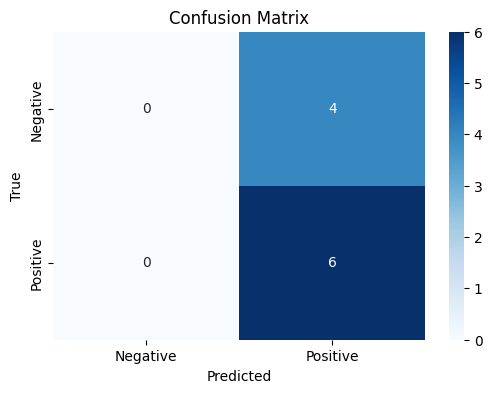


Classification Report:

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         4
    Positive       0.60      1.00      0.75         6

    accuracy                           0.60        10
   macro avg       0.30      0.50      0.38        10
weighted avg       0.36      0.60      0.45        10



c:\Users\dilip\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dilip\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\dilip\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [25]:
# Extract predictions and true labels
predictions = np.argmax(test_results.predictions, axis=-1)
true_labels = test_results.label_ids  # <-- FIX: Grabbing labels directly from the Trainer output

# Create the confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot it
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Print the final classification report
print("\nClassification Report:\n")
print(classification_report(true_labels, predictions, target_names=['Negative', 'Positive']))